## Импорты

In [43]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error, mean_squared_error
import lightgbm as lgb

# Пункт 1. Обучение baseline модели (1 балл)

## Решение
В этом блоке необходимо написать код. Можно создать столько ячеек с кодом, сколько нужно для выполнения задания

Шаблон кода по разбиению на train/test:
```
import pandas as pd

df = pd.read_csv("./data/train.csv")
df_train = df[df["timestamp"] < "2015-01-01"]
df_test = df["2015-01-01" <= df["timestamp"]]
```

## Загрузка и объединение данных

In [44]:
DATA_PATH = Path("resources")

train = pd.read_csv(DATA_PATH / 'train.csv')
test = pd.read_csv(DATA_PATH / 'test.csv')
macro = pd.read_csv(DATA_PATH / 'macro.csv')

# Преобразование timestamp
train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp'] = pd.to_datetime(test['timestamp'])
macro['timestamp'] = pd.to_datetime(macro['timestamp'])

# Присоединение макроэкономических показателей
train = train.merge(macro, on='timestamp', how='left')
test = test.merge(macro, on='timestamp', how='left')

# Разделение на train/validation по времени (согласно шаблону)
df_train = train[train['timestamp'] < '2015-01-01'].copy()
df_valid = train[train['timestamp'] >= '2015-01-01'].copy()


## Первичный анализ данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30471 entries, 0 to 30470
Columns: 391 entries, id to apartment_fund_sqm
dtypes: datetime64[ns](1), float64(213), int64(159), object(18)
memory usage: 90.9+ MB
None
                 id                      timestamp       full_sq  \
count  30471.000000                          30471  30471.000000   
mean   15237.917397  2013-12-21 16:45:41.911982080     54.214269   
min        1.000000            2011-08-20 00:00:00      0.000000   
25%     7620.500000            2013-04-25 00:00:00     38.000000   
50%    15238.000000            2014-02-19 00:00:00     49.000000   
75%    22855.500000            2014-09-24 00:00:00     63.000000   
max    30473.000000            2015-06-30 00:00:00   5326.000000   
std     8796.501536                            NaN     38.031487   

            life_sq         floor     max_floor      material    build_year  \
count  24088.000000  30304.000000  20899.000000  20899.000000  1.686600e+04   
mean      34.4

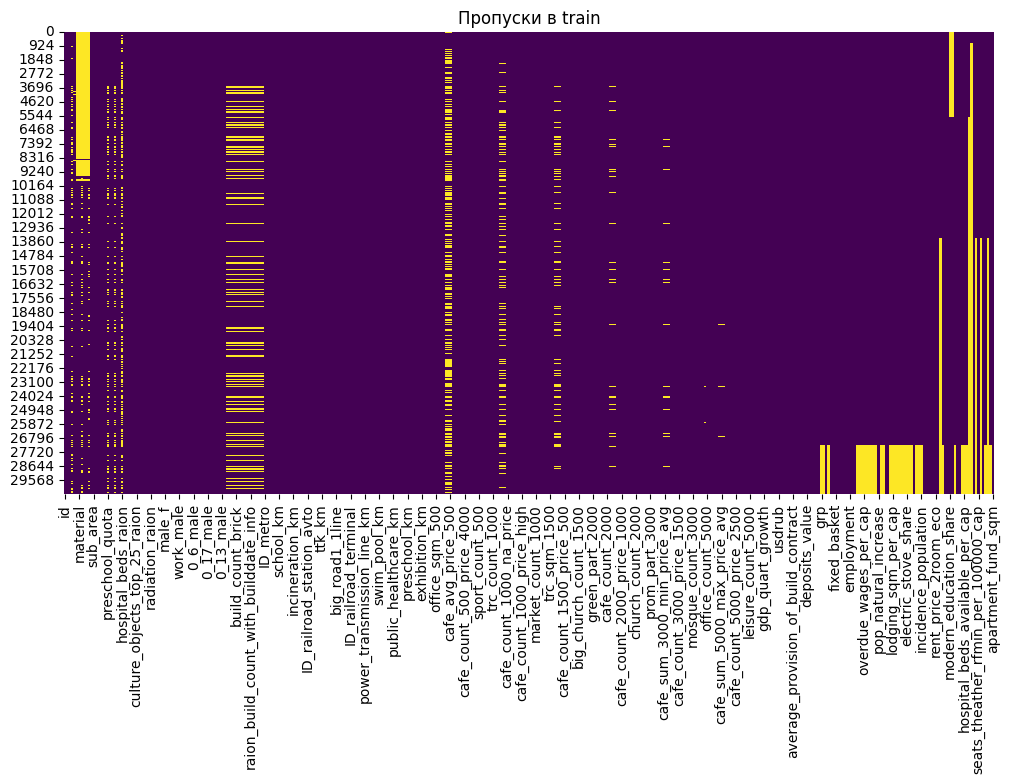

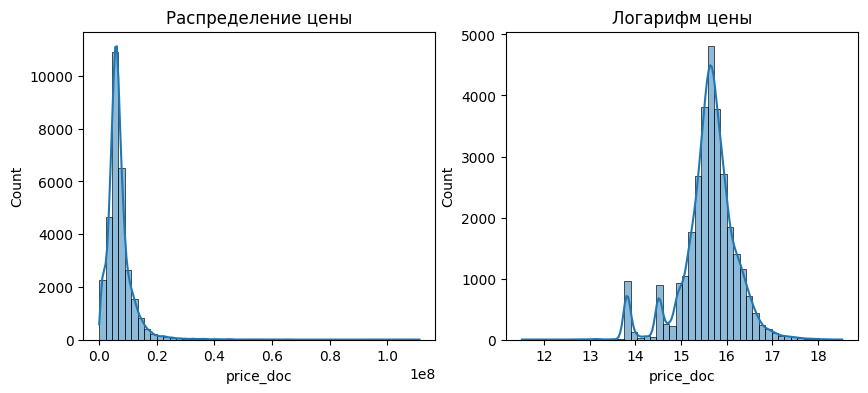

In [45]:
# Просмотр структуры
print(train.info())
print(train.describe())

# Визуализация пропусков
plt.figure(figsize=(12,6))
sns.heatmap(train.isnull(), cbar=False, cmap='viridis')
plt.title('Пропуски в train')
plt.show()

# Распределение цены
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(train['price_doc'], bins=50, kde=True)
plt.title('Распределение цены')
plt.subplot(1,2,2)
sns.histplot(np.log1p(train['price_doc']), bins=50, kde=True)
plt.title('Логарифм цены')
plt.show()

## Обработка пропусков и выбросов

In [48]:
# Пример обработки числовых признаков
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('price_doc')

# Заполнение пропусков медианой по подгруппам sub_area
for col in num_cols:
    train[col] = train[col].fillna(train.groupby('sub_area')[col].transform('median'))
    test[col] = test[col].fillna(test.groupby('sub_area')[col].transform('median'))

# Для оставшихся пропусков — глобальная медиана
global_medians = train[num_cols].median()
train[num_cols] = train[num_cols].fillna(global_medians)
test[num_cols] = test[num_cols].fillna(global_medians)

# Категориальные признаки
cat_cols = ['sub_area', 'ecology', 'product_type', 'culture_objects_top_25']  # и другие
for col in cat_cols:
    train[col] = train[col].fillna('Unknown')
    test[col] = test[col].fillna('Unknown')

## Инжиниринг признаков

In [54]:
# Отсекаем аномальные года постройки
train['build_year'] = train['build_year'].where((train['build_year'] > 1600) & (train['build_year'] < 2024), np.nan)
test['build_year'] = test['build_year'].where((test['build_year'] > 1600) & (test['build_year'] < 2024), np.nan)

# Глобальные медианы для подстраховки (на случай пустых групп)
global_median_train = train['build_year'].median()
global_median_test = test['build_year'].median()

# Функция заполнения: если в группе все NaN – использовать глобальную медиану
def fill_build_year(series, global_median):
    group_median = series.median()
    if pd.isna(group_median):
        return series.fillna(global_median)
    else:
        return series.fillna(group_median)

# Заполняем пропуски в build_year медианой по району
train['build_year'] = train.groupby('sub_area')['build_year'].transform(
    lambda x: fill_build_year(x, global_median_train)
)
test['build_year'] = test.groupby('sub_area')['build_year'].transform(
    lambda x: fill_build_year(x, global_median_test)
)

# Создаём все новые признаки в виде словаря Series
new_train_features = {
    'age': train['timestamp'].dt.year - train['build_year'],
    'life_sq_ratio': train['life_sq'] / train['full_sq'],
    'kitch_sq_ratio': train['kitch_sq'] / train['full_sq'],
    'floor_ratio': train['floor'] / train['max_floor']
}

new_test_features = {
    'age': test['timestamp'].dt.year - test['build_year'],
    'life_sq_ratio': test['life_sq'] / test['full_sq'],
    'kitch_sq_ratio': test['kitch_sq'] / test['full_sq'],
    'floor_ratio': test['floor'] / test['max_floor']
}

# Добавляем все признаки сразу, чтобы избежать фрагментации
train = pd.concat([train, pd.DataFrame(new_train_features)], axis=1)
test = pd.concat([test, pd.DataFrame(new_test_features)], axis=1)

## Подготовка признаков для модели

In [56]:
# Целевая переменная
y_train = np.log1p(df_train['price_doc'])
y_valid = np.log1p(df_valid['price_doc'])

# Признаки (исключаем id, timestamp, price_doc)
feature_cols = [col for col in df_train.columns if col not in ['id', 'timestamp', 'price_doc']]

X_train = df_train[feature_cols].copy()
X_valid = df_valid[feature_cols].copy()
X_test = test[feature_cols].copy()

# Убедимся, что все пропуски обработаны (только для числовых колонок)
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
X_train[num_cols] = X_train[num_cols].fillna(0)
X_valid[num_cols] = X_valid[num_cols].fillna(0)
X_test[num_cols] = X_test[num_cols].fillna(0)

## Обучение модели

In [ ]:
# Указываем категориальные признаки (если они не были закодированы)
cat_features = ['sub_area', 'ecology', 'product_type', 'culture_objects_top_25']  # и другие

# Убедимся, что категориальные признаки имеют правильный тип
for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_valid[col] = X_valid[col].astype('category')

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(50)],  # вместо early_stopping_rounds
    categorical_feature=cat_features
)

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: thermal_power_plant_raion: object, incineration_raion: object, oil_chemistry_raion: object, radiation_raion: object, railroad_terminal_raion: object, big_market_raion: object, nuclear_reactor_raion: object, detention_facility_raion: object, water_1line: object, big_road1_1line: object, railroad_1line: object, child_on_acc_pre_school: object, modern_education_share: object, old_education_build_share: object

## Ответ
В этом блоке необходимо вывести ответ для этой части задания. Ответ должен описаться на написанный код, построенные визуализации и проведенные расчеты. Если необходимо, то можно записать ответ в нескольких ячейках.

In [ ]:
# Оценка на валидации
pred_val = model.predict(X_val)
from sklearn.metrics import mean_squared_error
val_rmse = np.sqrt(mean_squared_error(y_val, pred_val))
print(f"RMSE на валидационной выборке: {val_rmse}")

# Предсказание на тестовых данных
print("Предсказание на тестовых данных...")
X_test_pool = Pool(X_test, cat_features=categorical_features)
predictions_log = model.predict(X_test_pool)
predictions = np.expm1(predictions_log)  # Обратное преобразование из логарифма

# Пункт 2. Улучшение baseline (1 балл)

## Решение
В этом блоке необходимо написать код. Можно создать столько ячеек с кодом, сколько нужно для выполнения задания

In [ ]:
# Здесь код решения

## Ответ
В этом блоке необходимо вывести ответ для этой части задания. Ответ должен описаться на написанный код, построенные визуализации и проведенные расчеты. Если необходимо, то можно записать ответ в нескольких ячейках.

In [ ]:
# Здесь код подготовки ответа и сам ответ

# Пункт 3. Отбор признаков (1 балл)

## Решение
В этом блоке необходимо написать код. Можно создать столько ячеек с кодом, сколько нужно для выполнения задания

In [ ]:
# Здесь код решения

## Ответ
В этом блоке необходимо вывести ответ для этой части задания. Ответ должен описаться на написанный код, построенные визуализации и проведенные расчеты. Если необходимо, то можно записать ответ в нескольких ячейках.

In [ ]:
# Здесь код подготовки ответа и сам ответ

# Пункт 4. Eval feature (опциональный пункт, 1 балл)

## Решение
В этом блоке необходимо написать код. Можно создать столько ячеек с кодом, сколько нужно для выполнения задания

In [ ]:
# Здесь код решения

## Ответ
В этом блоке необходимо вывести ответ для этой части задания. Ответ должен описаться на написанный код, построенные визуализации и проведенные расчеты. Если необходимо, то можно записать ответ в нескольких ячейках.

In [ ]:
# Здесь код подготовки ответа и сам ответ